# Indoor Walk Test Methods Notebook

This notebook is a fresh methods scaffold for importing walk-test CSV exports, reducing them to a common schema, georeferencing them to the floor plan, and plotting signal metrics on top of the map.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import ScalarMappable
from scipy.ndimage import binary_closing, binary_fill_holes, label

In [ ]:
UNITS = {
    'rsrp': 'dBm',
    'rsrq': 'dB',
    'cinr': 'dB',
    'rssi': 'dBm',
    'tests': 'count',
    'pci': '',
    'freq': 'MHz',
    'band': '',
    'network': '',
    'source': '',
}

# Hard physical bounds per metric, used to clamp the auto-scaled (quantile-based)
# color ranges in the plotting functions below so a few outlier readings can't
# blow out the color scale.
SIGNAL_RANGES = {
    'rsrp': (-140, -44),
    'rsrq': (-43, 20),
    'cinr': (-23, 40),
    'rssi': (-100, 0),
}

METRICS = ['rsrp', 'rsrq', 'cinr', 'rssi']
NUM_COLS = ['rsrp', 'rsrq', 'cinr', 'rssi']
ID_COLS = {'pci', 'freq', 'band', 'network'}
OTHER = {'source', 'n_samples'}

DATA_DIR = Path('./Data')
CSV_DIR = Path('./CSV') if Path('./CSV').exists() else DATA_DIR / 'WHOLE LOT OF csv'

FLOOR_MAP_PNG = './7th_Floor_2nd_Indoor_Walk_Test_V2.2.png'
FLOOR_MAP_TAB = './7th_Floor_2nd_Indoor_Walk_Test_V2.2.TAB'

PAT_LTE_BLIND = '*LTE*DL_Blind Scan.CSV'
PAT_LTE_TOPN = '*Enhanced Top N Signal*MHz.CSV'
PAT_NR_TOPN = '*nr Top N Signal*kHz.CSV'
PAT_BEST_SERVING = '*_BestServing.CSV'

In [ ]:
# Device exports "Time" as H:M:S:millis (colon-separated, not decimal), so this
# hand-parses it instead of relying on a strptime format string.
def time_to_millisec(time_value):
    parts = str(time_value).split(':')
    h, m, s, millis = int(parts[0]), int(parts[1]), int(parts[2]), int(float(parts[3]))
    return h * 3600000 + m * 60000 + s * 1000 + millis


def read_csv(path):
    return pd.read_csv(path)


def read_concat_csvs(pattern, exclude='_BestServing'):
    frames = []
    for path in sorted(CSV_DIR.glob(pattern)):
        if exclude and exclude in path.name:
            continue
        df = read_csv(path)
        df['source'] = path.stem
        frames.append(df)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


# reduce_* functions map each scan type's raw column names onto the shared
# schema (latitude/longitude/pci/freq/rsrp/rsrq/cinr/rssi/network) so
# different protocols can be plotted with the same functions below.
def reduce_lte_blind(df):
    df = df.rename(columns={
        'Latitude': 'latitude',
        'Longitude': 'longitude',
        'Cell Id': 'pci',
        'Channel Number': 'freq',
        'Channel RSSI': 'rssi',
        'Ref Signal - Received Power': 'rsrp',
        'Ref Signal - Received Quality': 'rsrq',
        'Ref Signal - CINR': 'cinr',
    })
    df['time(ms)'] = df['Time'].apply(time_to_millisec)
    df['network'] = 'lte'
    columns = ['time(ms)', 'latitude', 'longitude', 'pci', 'freq', 'rsrp', 'rsrq', 'cinr', 'rssi', 'network', 'source']
    return df[columns].copy()


def reduce_nr_topn(df):
    df = df.rename(columns={
        'Latitude': 'latitude',
        'Longitude': 'longitude',
        'Cell ID': 'pci',
        'Channel Frequency': 'freq',
        'SSB RSSI': 'rssi',
        'SSS_RP': 'rsrp',
        'SSS_RQ': 'rsrq',
        'SS_CINR': 'cinr',
        'Band': 'band',
    })
    df['time(ms)'] = df['System Time'].apply(time_to_millisec)
    df['network'] = 'nr'
    columns = ['time(ms)', 'latitude', 'longitude', 'pci', 'freq', 'rsrp', 'rsrq', 'cinr', 'rssi', 'band', 'network', 'source']
    return df[columns].copy()

In [ ]:
# The .TAB file embeds ground control points as "(lon,lat) (px,py)" pairs —
# pull those out with regex rather than parsing the full MapInfo grammar.
def read_tab_gcps(tab_path):
    pattern = re.compile(r'\((-?[\d.]+),(-?[\d.]+)\)\s*\((\d+),(\d+)\)')
    gcps = []
    for line in Path(tab_path).read_text().splitlines():
        match = pattern.search(line)
        if match:
            lon, lat, px, py = map(float, match.groups())
            gcps.append((lon, lat, px, py))
    return pd.DataFrame(gcps, columns=['longitude', 'latitude', 'px', 'py'])


# Least-squares fit of px = a*lon + b*lat + c (and same for py) over the GCPs —
# a simple affine georeference, good enough since the floor plan isn't rotated
# or curved relative to true north. RMSE reported is the fit residual in pixels.
def fit_affine(gcps):
    A = np.column_stack([gcps['longitude'], gcps['latitude'], np.ones(len(gcps))])
    coef_x, *_ = np.linalg.lstsq(A, gcps['px'], rcond=None)
    coef_y, *_ = np.linalg.lstsq(A, gcps['py'], rcond=None)

    res_x = A @ coef_x - gcps['px']
    res_y = A @ coef_y - gcps['py']
    rmse = np.sqrt(np.mean(res_x ** 2 + res_y ** 2))
    print(f'affine fit rmse: {rmse:.1f} px over {len(gcps)} GCPs')

    return coef_x, coef_y


def add_pixel_coords(df, coef_x, coef_y):
    df = df.copy()
    A = np.column_stack([df['longitude'], df['latitude'], np.ones(len(df))])
    df['px'] = A @ coef_x
    df['py'] = A @ coef_y
    return df


# Derives the floor plan's outline from the PNG itself: threshold dark ("ink")
# pixels, close small gaps so the outline forms a solid region, fill any
# enclosed holes, then keep only the largest connected component (the floor
# boundary) in case stray marks/text created smaller disconnected blobs.
def floor_footprint(image_path, ink_thresh=0.95, close_px=15):
    image = mpimg.imread(image_path)
    if image.ndim == 3:
        gray = image[:, :, :3].mean(axis=2)
    else:
        gray = image

    mask = gray < ink_thresh
    mask = binary_closing(mask, structure=np.ones((close_px, close_px), dtype=bool))
    mask = binary_fill_holes(mask)

    labeled, n_regions = label(mask)
    if n_regions == 0:
        return image, mask

    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = sizes.argmax()
    mask = labeled == largest
    return image, mask

In [ ]:
def plot_floor_signal(
    df,
    metric,
    title=None,
    figsize=(14, 8),
    cmap='viridis',
    vmin=None,
    vmax=None,
    point_size=60,
    show_boundary=True,
    boundary_color='red',
    boundary_width=2,
    boundary_ink_thresh=0.95,
    boundary_close_px=15,
    boundary_warp_gcp=True,
    gcp_points=None,
    lock_to_map=True,
    boundary_mode='auto',
    boundary_regular_color='orange',
    boundary_warp_color='cyan',
    save_path=None,
    show=True,
    add_wrap_png=False,
    wrap_save_path=None,
    wrap_boundary_mode='both',
    wrap_show=False,
):
    unit = UNITS.get(metric, '')
    col_data = df[metric].dropna()
    if col_data.empty:
        raise ValueError(f'No non-null values found for metric: {metric}')

    # Auto-scale the color range to the 2nd-98th percentile so a handful of
    # extreme readings don't wash out the rest of the map.
    vmin = vmin if vmin is not None else col_data.quantile(0.02)
    vmax = vmax if vmax is not None else col_data.quantile(0.98)

    img = mpimg.imread(FLOOR_MAP_PNG)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)

    if show_boundary:
        _, mask = floor_footprint(FLOOR_MAP_PNG, ink_thresh=boundary_ink_thresh, close_px=boundary_close_px)

        def draw_regular(color):
            ax.contour(mask.astype(float), levels=[0.5], colors=color, linewidths=boundary_width)

        # "Warped" boundary: the floor_footprint mask is derived straight from
        # the raw PNG pixels, but if the PNG has been re-warped/cropped from
        # what the GCPs were measured against, that outline can drift from the
        # georeferenced points. This re-projects the outline through the
        # inverse of the GCP affine fit (px,py -> lon,lat -> px,py again via
        # coef_x/coef_y) so it lines up with the actual plotted data.
        def draw_warped(color):
            gcp_df = gcp_points if gcp_points is not None else globals().get('gcps', None)
            cx = globals().get('coef_x', None)
            cy = globals().get('coef_y', None)
            can_warp = gcp_df is not None and cx is not None and cy is not None and len(gcp_df) >= 3
            if not can_warp:
                return False

            A_inv = np.column_stack([gcp_df['px'], gcp_df['py'], np.ones(len(gcp_df))])
            coef_lon, *_ = np.linalg.lstsq(A_inv, gcp_df['longitude'], rcond=None)
            coef_lat, *_ = np.linalg.lstsq(A_inv, gcp_df['latitude'], rcond=None)

            contour = ax.contour(mask.astype(float), levels=[0.5], colors='none', linewidths=0)
            segments = contour.allsegs[0] if hasattr(contour, 'allsegs') and contour.allsegs else []
            try:
                contour.remove()
            except Exception:
                pass

            for segment in segments:
                if len(segment) < 2:
                    continue
                B = np.column_stack([segment[:, 0], segment[:, 1], np.ones(len(segment))])
                lon = B @ coef_lon
                lat = B @ coef_lat
                A = np.column_stack([lon, lat, np.ones(len(segment))])
                xw = A @ cx
                yw = A @ cy
                ax.plot(xw, yw, color=color, linewidth=boundary_width)
            return True

        mode = boundary_mode if boundary_mode in {'regular', 'warped', 'both'} else ('warped' if boundary_warp_gcp else 'regular')
        if mode == 'regular':
            draw_regular(boundary_color)
        elif mode == 'warped':
            if not draw_warped(boundary_color):
                draw_regular(boundary_color)
        else:
            draw_regular(boundary_regular_color)
            draw_warped(boundary_warp_color)

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    ax.scatter(
        df['px'],
        df['py'],
        c=df[metric],
        cmap=cmap,
        norm=norm,
        s=point_size,
        edgecolors='black',
        linewidths=0.3,
        alpha=0.9,
    )

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.7, pad=0.01)
    cbar.set_label(f'{metric.upper()} ({unit})', fontsize=11)
    ticks = np.linspace(vmin, vmax, 9)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f'{tick:.0f} {unit}' for tick in ticks])
    cbar.ax.tick_params(labelsize=8)

    if lock_to_map:
        height, width = img.shape[:2]
        ax.set_xlim(0, width)
        ax.set_ylim(height, 0)

    ax.set_axis_off()
    ax.set_title(title or f'{metric.upper()} ({unit}) — 7th floor walk test', fontsize=13, pad=10)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=220, bbox_inches='tight')

    if show:
        plt.show()
    else:
        plt.close(fig)

    # Optionally re-render a second copy with the "wrapped" (GCP-reprojected)
    # boundary style, e.g. for side-by-side comparison against the regular one.
    if add_wrap_png:
        wrap_out = wrap_save_path
        if wrap_out is None and save_path:
            save_path = Path(save_path)
            wrap_out = save_path.with_name(f'{save_path.stem}_wrapped{save_path.suffix}')

        plot_floor_signal(
            df=df,
            metric=metric,
            title=(title + ' — wrapped boundary') if title else None,
            figsize=figsize,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            point_size=point_size,
            show_boundary=show_boundary,
            
            boundary_color=boundary_color,
            boundary_width=boundary_width,
            boundary_ink_thresh=boundary_ink_thresh,
            boundary_close_px=boundary_close_px,
            boundary_warp_gcp=boundary_warp_gcp,
            gcp_points=gcp_points,
            lock_to_map=lock_to_map,
            boundary_mode=wrap_boundary_mode,
            boundary_regular_color=boundary_regular_color,
            boundary_warp_color=boundary_warp_color,
            save_path=wrap_out,
            show=wrap_show,
            add_wrap_png=False,
        )

In [6]:
# Example setup
# gcps = read_tab_gcps(FLOOR_MAP_TAB)
# coef_x, coef_y = fit_affine(gcps)
# lte_blind = read_concat_csvs(PAT_LTE_BLIND)
# lte_reduced = reduce_lte_blind(lte_blind)
# lte_reduced = add_pixel_coords(lte_reduced, coef_x, coef_y)
# plot_floor_signal(lte_reduced, 'rsrp', title='LTE RSRP')

In [ ]:
MERGED_CSV = Path('./Concat_Indoor_Walk_Test_from_csv.csv')
PAT_GENERIC_BLIND = '*Blind Scan*.CSV'
PAT_GENERIC_NR_TOPN = '*nr Top N Signal*.CSV'


# Neither Blind Scan file has an explicit protocol column, so infer it from
# the filename convention the collection tool uses (e.g. "..._NR_FR1...",
# "..._TD-LTE...").
def infer_network_protocol(source_value):
    source_text = str(source_value).upper()
    if 'NR_' in source_text or '_NR' in source_text or ' NR ' in source_text:
        return 'nr'
    if 'TD-LTE' in source_text or 'LTE' in source_text:
        return 'lte'
    if 'UMTS' in source_text:
        return 'umts'
    return 'unknown'


# Prefer an explicit Band column when present; otherwise fall back to
# parsing the band/NR-ARFCN designator out of the source filename (e.g.
# "..._NR_FR1 FDD n25..." -> "n25", "..._LTE_EB 07..." -> "B7").
def infer_discrete_band(source_value, network_value='unknown', band_value=None):
    if pd.notna(band_value) and str(band_value).strip() and str(band_value).strip().lower() != 'nan':
        return str(band_value).strip()

    source_text = str(source_value)

    if network_value == 'nr':
        match = re.search(r'\b(n\d+)\b', source_text, flags=re.IGNORECASE)
        if match:
            return match.group(1).lower()

    if network_value == 'lte':
        match = re.search(r'(?:LTE_EB|TD-LTE_EB)\s+(\d+)', source_text, flags=re.IGNORECASE)
        if match:
            return f'B{match.group(1)}'

    cleaned = re.sub(r'\.CSV$', '', Path(source_text).name, flags=re.IGNORECASE)
    return cleaned.strip()


# Great-circle distance between two lat/lon points, vectorized over arrays.
def haversine_meters(lat1, lon1, lat2, lon2):
    lat1 = np.radians(np.asarray(lat1, dtype=float))
    lon1 = np.radians(np.asarray(lon1, dtype=float))
    lat2 = np.radians(np.asarray(lat2, dtype=float))
    lon2 = np.radians(np.asarray(lon2, dtype=float))

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371000.0 * c


def prepare_blind_rsrp_dataframe(csv_dir=CSV_DIR, pattern=PAT_GENERIC_BLIND):
    frames = []
    for path in sorted(Path(csv_dir).glob(pattern)):
        if 'Spectrum' in path.name or '_BestServing' in path.name:
            continue
        df = pd.read_csv(path)
        df['source'] = path.stem
        frames.append(df)

    if not frames:
        return pd.DataFrame(columns=['latitude', 'longitude', 'rsrp', 'network', 'band', 'source'])

    df = pd.concat(frames, ignore_index=True)
    source_series = df['source'].fillna('')
    df['latitude'] = pd.to_numeric(df.get('Latitude'), errors='coerce')
    df['longitude'] = pd.to_numeric(df.get('Longitude'), errors='coerce')
    df['rsrp'] = pd.to_numeric(df.get('Ref Signal - Received Power'), errors='coerce')
    df['source'] = source_series
    df['network'] = df['source'].apply(infer_network_protocol)
    df['band'] = [
        infer_discrete_band(source_value, network_value, band_value)
        for source_value, network_value, band_value in zip(df['source'], df['network'], df.get('Band', pd.Series(index=df.index)))
    ]

    columns = ['latitude', 'longitude', 'rsrp', 'network', 'band', 'source']
    df = df[columns].dropna(subset=['latitude', 'longitude', 'rsrp'])
    return df.reset_index(drop=True)


def prepare_nr_topn_rsrp_dataframe(csv_dir=CSV_DIR, pattern=PAT_GENERIC_NR_TOPN):
    frames = []
    for path in sorted(Path(csv_dir).glob(pattern)):
        if '_BestServing' in path.name:
            continue
        df = pd.read_csv(path)
        df['source'] = path.stem
        frames.append(df)

    if not frames:
        return pd.DataFrame(columns=['latitude', 'longitude', 'rsrp', 'network', 'band', 'source'])

    df = pd.concat(frames, ignore_index=True)
    df['latitude'] = pd.to_numeric(df.get('Latitude'), errors='coerce')
    df['longitude'] = pd.to_numeric(df.get('Longitude'), errors='coerce')
    df['rsrp'] = pd.to_numeric(df.get('SSS_RP'), errors='coerce')
    df['source'] = df['source'].fillna('')
    df['network'] = 'nr_fr1'
    df['band'] = [
        infer_discrete_band(source_value, 'nr', band_value)
        for source_value, band_value in zip(df['source'], df.get('Band', pd.Series(index=df.index)))
    ]

    columns = ['latitude', 'longitude', 'rsrp', 'network', 'band', 'source']
    df = df[columns].dropna(subset=['latitude', 'longitude', 'rsrp'])
    return df.reset_index(drop=True)


# Quick data-quality check: for each protocol/scan-type glob, how many files
# matched and how many rows actually had a usable metric value.
def build_protocol_availability_report(csv_dir=CSV_DIR):
    csv_dir = Path(csv_dir)
    rows = []
    protocol_patterns = [
        ('lte_and_td_lte_blind', '*LTE*Blind Scan*.CSV', 'Ref Signal - Received Power'),
        ('nr_fr1_blind', '*NR_FR1*Blind Scan*.CSV', 'SSS_RP'),
        ('nr_fr1_topn', '*NR_FR1*Top N Signal*.CSV', 'SSS_RP'),
        ('nr_fr2_blind', '*NR_FR2*Blind Scan*.CSV', 'SSS_RP'),
        ('td_lte_blind', '*TD-LTE*Blind Scan*.CSV', 'Ref Signal - Received Power'),
    ]

    for protocol_name, pattern, metric_column in protocol_patterns:
        files = [path for path in sorted(csv_dir.glob(pattern)) if 'Spectrum' not in path.name and '_BestServing' not in path.name]
        rows_in_metric = 0
        for path in files:
            df = pd.read_csv(path)
            if metric_column in df.columns:
                rows_in_metric += int(pd.to_numeric(df[metric_column], errors='coerce').notna().sum())
        rows.append({
            'protocol_group': protocol_name,
            'files': len(files),
            'metric_column': metric_column,
            'rows_with_metric': rows_in_metric,
        })

    return pd.DataFrame(rows)


def prepare_coordinate_rsrp_dataframe(csv_dir=CSV_DIR):
    blind_df = prepare_blind_rsrp_dataframe(csv_dir)
    nr_topn_df = prepare_nr_topn_rsrp_dataframe(csv_dir)
    combined = pd.concat([blind_df, nr_topn_df], ignore_index=True)
    combined['network'] = combined['network'].replace({'nr': 'nr_blind', 'lte': 'lte_blind'})
    return combined.dropna(subset=['latitude', 'longitude', 'rsrp']).reset_index(drop=True)


def aggregate_exact_coordinates(df):
    grouped = df.groupby(['network', 'band', 'latitude', 'longitude'], as_index=False).agg(
        avg_rsrp=('rsrp', 'mean'),
        n_measurements=('rsrp', 'size'),
        sources=('source', lambda values: '; '.join(sorted(set(map(str, values)))))
    )
    return grouped


# GPS fixes repeat/jitter around the same physical spot, so exact-coordinate
# grouping alone leaves near-duplicate points. This greedily merges any
# points within merge_radius_m of a "seed" point into one weighted-average
# cluster, then repeats on the remainder until every point is assigned.
def cluster_measurements_by_distance(df, merge_radius_m=5.0):
    clustered_frames = []
    grouped = aggregate_exact_coordinates(df)

    for (network_value, band_value), group in grouped.groupby(['network', 'band'], sort=True):
        remaining = group.reset_index(drop=True).copy()
        clusters = []

        while not remaining.empty:
            seed = remaining.iloc[0]
            distances = haversine_meters(
                seed['latitude'],
                seed['longitude'],
                remaining['latitude'].to_numpy(),
                remaining['longitude'].to_numpy(),
            )
            cluster_rows = remaining.loc[distances <= merge_radius_m].copy()
            remaining = remaining.loc[distances > merge_radius_m].reset_index(drop=True)

            weights = cluster_rows['n_measurements'].to_numpy(dtype=float)
            clusters.append({
                'network': network_value,
                'band': band_value,
                'latitude': np.average(cluster_rows['latitude'], weights=weights),
                'longitude': np.average(cluster_rows['longitude'], weights=weights),
                'avg_rsrp': np.average(cluster_rows['avg_rsrp'], weights=weights),
                'n_measurements': int(cluster_rows['n_measurements'].sum()),
                'n_points': int(len(cluster_rows)),
                'sources': '; '.join(sorted(set('; '.join(cluster_rows['sources']).split('; ')))),
            })

        clustered_frames.append(pd.DataFrame(clusters))

    if not clustered_frames:
        return pd.DataFrame(columns=['network', 'band', 'latitude', 'longitude', 'avg_rsrp', 'n_measurements', 'n_points', 'sources'])

    return pd.concat(clustered_frames, ignore_index=True)


# For each query coordinate, find clustered measurement points within
# [min_radius_m, max_radius_m] and summarize RSRP per network/band — used to
# answer "what's the signal like near this specific spot on the floor plan?"
def summarize_rsrp_near_coordinates(clustered_df, coordinates, min_radius_m=0.0, max_radius_m=10.0):
    summaries = []

    for query_index, (latitude, longitude) in enumerate(coordinates, start=1):
        distances = haversine_meters(
            latitude,
            longitude,
            clustered_df['latitude'].to_numpy(),
            clustered_df['longitude'].to_numpy(),
        )
        nearby = clustered_df.loc[(distances >= min_radius_m) & (distances <= max_radius_m)].copy()
        if nearby.empty:
            continue

        nearby['distance_m'] = distances[(distances >= min_radius_m) & (distances <= max_radius_m)]
        summary = nearby.groupby(['network', 'band'], as_index=False).agg(
            avg_rsrp=('avg_rsrp', 'mean'),
            closest_distance_m=('distance_m', 'min'),
            matched_clusters=('avg_rsrp', 'size'),
            matched_measurements=('n_measurements', 'sum')
        )
        summary.insert(0, 'query_index', query_index)
        summary.insert(1, 'query_latitude', latitude)
        summary.insert(2, 'query_longitude', longitude)
        summaries.append(summary.sort_values(['network', 'band']).reset_index(drop=True))

    if not summaries:
        return pd.DataFrame(columns=['query_index', 'query_latitude', 'query_longitude', 'network', 'band', 'avg_rsrp', 'closest_distance_m', 'matched_clusters', 'matched_measurements'])

    result = pd.concat(summaries, ignore_index=True)
    return result.sort_values(['query_index', 'network', 'band']).reset_index(drop=True)


def print_rsrp_coordinate_summary(summary_df):
    if summary_df.empty:
        print('No blind-scan RSRP measurements matched the requested coordinates and distance window.')
        return

    for query_index, group in summary_df.groupby('query_index', sort=True):
        row = group.iloc[0]
        print(f"Coordinate {query_index}: ({row['query_latitude']:.6f}, {row['query_longitude']:.6f})")
        display_df = group[['network', 'band', 'avg_rsrp', 'closest_distance_m', 'matched_clusters', 'matched_measurements']].copy()
        display_df['avg_rsrp'] = display_df['avg_rsrp'].round(2)
        display_df['closest_distance_m'] = display_df['closest_distance_m'].round(2)
        print(display_df.to_string(index=False))
        print()

In [8]:
blind_rsrp_df = prepare_blind_rsrp_dataframe(CSV_DIR)
nr_topn_rsrp_df = prepare_nr_topn_rsrp_dataframe(CSV_DIR)
coordinate_rsrp_df = prepare_coordinate_rsrp_dataframe(CSV_DIR)
availability_report = build_protocol_availability_report(CSV_DIR)
clustered_blind_rsrp_df = cluster_measurements_by_distance(coordinate_rsrp_df, merge_radius_m=5.0)

coordinates = [
    (38.903461, -77.007583),
    (38.902618, -77.008523),
]

rsrp_summary = summarize_rsrp_near_coordinates(
    clustered_blind_rsrp_df,
    coordinates=coordinates,
    min_radius_m=0.0,
    max_radius_m=10.0,
)

print('Protocol availability from CSV exports:')
print(availability_report.to_string(index=False))
print()
print_rsrp_coordinate_summary(rsrp_summary)
rsrp_summary

Protocol availability from CSV exports:
      protocol_group  files               metric_column  rows_with_metric
lte_and_td_lte_blind     71 Ref Signal - Received Power              5269
        nr_fr1_blind     50                      SSS_RP                 0
         nr_fr1_topn      7                      SSS_RP              1832
        nr_fr2_blind      6                      SSS_RP                 0
        td_lte_blind     22 Ref Signal - Received Power                 0

Coordinate 1: (38.903461, -77.007583)
  network                                                             band  avg_rsrp  closest_distance_m  matched_clusters  matched_measurements
lte_blind                                                              B01   -101.74                0.45                 4                    29
lte_blind                                                              B02    -94.00                0.67                 4                    24
lte_blind                                 

,query_index,query_latitude,query_longitude,network,band,avg_rsrp,closest_distance_m,matched_clusters,matched_measurements
0,1,38.903461,-77.007583,lte_blind,B01,-101.742750,0.452517,4,29
1,1,38.903461,-77.007583,lte_blind,B02,-94.000042,0.665834,4,24
2,1,38.903461,-77.007583,lte_blind,B04,-104.442396,1.339396,4,18
3,1,38.903461,-77.007583,lte_blind,B10,-102.193375,0.975810,4,28
4,1,38.903461,-77.007583,lte_blind,B12,-97.286830,1.064520,4,25
5,1,38.903461,-77.007583,lte_blind,B13,-110.095625,1.463716,4,10
6,1,38.903461,-77.007583,lte_blind,B14,-109.240208,1.301081,4,20
7,1,38.903461,-77.007583,lte_blind,B17,-104.280774,1.254613,4,15
8,1,38.903461,-77.007583,lte_blind,B25,-93.734279,1.048649,4,24
9,1,38.903461,-77.007583,lte_blind,B28,-109.378125,1.234439,4,20


In [ ]:
# This is the main NR Top-N reduction used to build the HTML dashboard's
# point data: keeps pci/freq/band/rsrp/rsrq/cinr/rssi per raw measurement
# (no aggregation yet) and tags network as nr_fr1/nr_fr2 from the filename.
def prepare_nr_topn_metrics_dataframe(csv_dir=CSV_DIR, pattern=PAT_GENERIC_NR_TOPN):
    frames = []
    for path in sorted(Path(csv_dir).glob(pattern)):
        if '_BestServing' in path.name:
            continue
        df = pd.read_csv(path)
        df['source'] = path.stem
        frames.append(df)

    if not frames:
        return pd.DataFrame(columns=['latitude', 'longitude', 'pci', 'freq', 'band', 'network', 'rsrp', 'rsrq', 'cinr', 'rssi', 'source'])

    df = pd.concat(frames, ignore_index=True)
    df = df.rename(columns={
        'Latitude': 'latitude',
        'Longitude': 'longitude',
        'Cell ID': 'pci',
        'Channel Frequency': 'freq',
        'Band': 'band',
        'SSS_RP': 'rsrp',
        'SSS_RQ': 'rsrq',
        'SS_CINR': 'cinr',
        'SSB RSSI': 'rssi',
    })

    for metric in ['latitude', 'longitude', 'pci', 'freq', 'band', 'rsrp', 'rsrq', 'cinr', 'rssi']:
        if metric in df.columns:
            df[metric] = pd.to_numeric(df[metric], errors='coerce')

    df['network'] = df['source'].str.upper().map(
        lambda value: 'nr_fr2' if 'NR_FR2' in value else ('nr_fr1' if 'NR_FR1' in value else 'nr_unknown')
    )

    columns = ['latitude', 'longitude', 'pci', 'freq', 'band', 'network', 'rsrp', 'rsrq', 'cinr', 'rssi', 'source']
    return df[columns].dropna(subset=['latitude', 'longitude']).reset_index(drop=True)


# Collapses repeated measurements at the same (network, band, lat, lon) into
# one row per coordinate — averaging the signal metrics and recording
# n_samples so the map can show how many readings backed each point. This is
# what the HTML "records" (coverage map) dataset is built from; it drops
# per-measurement timing, which is why the time-elapsed playback feature
# reads from the separate, non-aggregated timeseries export instead.
def average_metrics_by_coordinate(df):
    metric_columns = ['rsrp', 'rsrq', 'cinr', 'rssi']
    aggregations = {metric: 'mean' for metric in metric_columns}
    aggregations['source'] = lambda values: '; '.join(sorted(set(map(str, values))))
    aggregations['pci'] = 'first'
    aggregations['freq'] = 'first'

    grouped = df.groupby(['network', 'band', 'latitude', 'longitude'], as_index=False).agg(aggregations)
    grouped['n_samples'] = df.groupby(['network', 'band', 'latitude', 'longitude']).size().values
    return grouped


# Auto-scaled color range for a metric: start from the requested quantile
# window, then clamp to the metric's hard physical bounds (SIGNAL_RANGES) so
# a skewed sample can't produce a nonsensical range.
def resolve_metric_range(metric_values, metric, quantiles=(0.10, 0.90)):
    lower_q, upper_q = quantiles
    vmin = float(metric_values.quantile(lower_q))
    vmax = float(metric_values.quantile(upper_q))
    default_range = SIGNAL_RANGES.get(metric)
    if default_range is not None:
        range_min, range_max = default_range
        vmin = max(vmin, range_min)
        vmax = min(vmax, range_max)
    if vmin == vmax:
        vmin = float(metric_values.min())
        vmax = float(metric_values.max())
    return vmin, vmax


# 2x2 grid of scatter plots (one per metric) over the floor plan.
def plot_floor_metric_grid(df, metrics=('rsrp', 'rsrq', 'cinr', 'rssi'), title_prefix='NR FR1 Band 2', figsize=(16, 12), point_size=55, quantiles=(0.10, 0.90)):
    gcps = read_tab_gcps(FLOOR_MAP_TAB)
    coef_x, coef_y = fit_affine(gcps)
    plot_df = add_pixel_coords(df, coef_x, coef_y)

    img = mpimg.imread(FLOOR_MAP_PNG)
    _, mask = floor_footprint(FLOOR_MAP_PNG)

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.ravel()

    for ax, metric in zip(axes, metrics):
        ax.imshow(img)
        ax.contour(mask.astype(float), levels=[0.5], colors='white', linewidths=1.2)

        metric_values = plot_df[metric].dropna()
        if metric_values.empty:
            ax.set_title(f'{metric.upper()} (no data)')
            ax.set_axis_off()
            continue

        vmin, vmax = resolve_metric_range(metric_values, metric, quantiles=quantiles)
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        scatter = ax.scatter(
            plot_df['px'],
            plot_df['py'],
            c=plot_df[metric],
            cmap='viridis',
            norm=norm,
            s=point_size,
            edgecolors='black',
            linewidths=0.25,
            alpha=0.9,
        )

        colorbar = fig.colorbar(scatter, ax=ax, shrink=0.75, pad=0.01)
        colorbar.set_label(f'{metric.upper()} ({UNITS.get(metric, '')})', fontsize=10)
        ax.set_title(f'{title_prefix} {metric.upper()}')
        height, width = img.shape[:2]
        ax.set_xlim(0, width)
        ax.set_ylim(height, 0)
        ax.set_axis_off()

    fig.tight_layout()
    plt.show()


# Same 2x2 layout, but interpolates a continuous filled-contour surface
# (tricontourf) between the sample points instead of discrete markers — the
# matplotlib equivalent of the HTML dashboard's "Gradient Coverage" mode.
def plot_floor_metric_gradient_grid(df, metrics=('rsrp', 'rsrq', 'cinr', 'rssi'), title_prefix='NR FR1 Band 2 Gradient', figsize=(16, 12), quantiles=(0.10, 0.90), contour_levels=18):
    gcps = read_tab_gcps(FLOOR_MAP_TAB)
    coef_x, coef_y = fit_affine(gcps)
    plot_df = add_pixel_coords(df, coef_x, coef_y)

    img = mpimg.imread(FLOOR_MAP_PNG)
    _, mask = floor_footprint(FLOOR_MAP_PNG)
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.ravel()

    for ax, metric in zip(axes, metrics):
        ax.imshow(img)
        ax.contour(mask.astype(float), levels=[0.5], colors='white', linewidths=1.0)

        metric_df = plot_df[['px', 'py', metric]].dropna().copy()
        if len(metric_df) < 3:
            ax.set_title(f'{metric.upper()} (insufficient data)')
            ax.set_axis_off()
            continue

        vmin, vmax = resolve_metric_range(metric_df[metric], metric, quantiles=quantiles)
        levels = np.linspace(vmin, vmax, contour_levels)
        contour = ax.tricontourf(
            metric_df['px'],
            metric_df['py'],
            metric_df[metric],
            levels=levels,
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            alpha=0.82,
        )
        ax.scatter(metric_df['px'], metric_df['py'], s=10, c='black', alpha=0.25)

        colorbar = fig.colorbar(contour, ax=ax, shrink=0.75, pad=0.01)
        colorbar.set_label(f'{metric.upper()} ({UNITS.get(metric, '')})', fontsize=10)
        ax.set_title(f'{title_prefix} {metric.upper()}')
        height, width = img.shape[:2]
        ax.set_xlim(0, width)
        ax.set_ylim(height, 0)
        ax.set_axis_off()

    fig.tight_layout()
    plt.show()

nr_fr1_band2_rows=375
nr_fr1_band2_unique_coordinates=277
affine fit rmse: 0.0 px over 3 GCPs


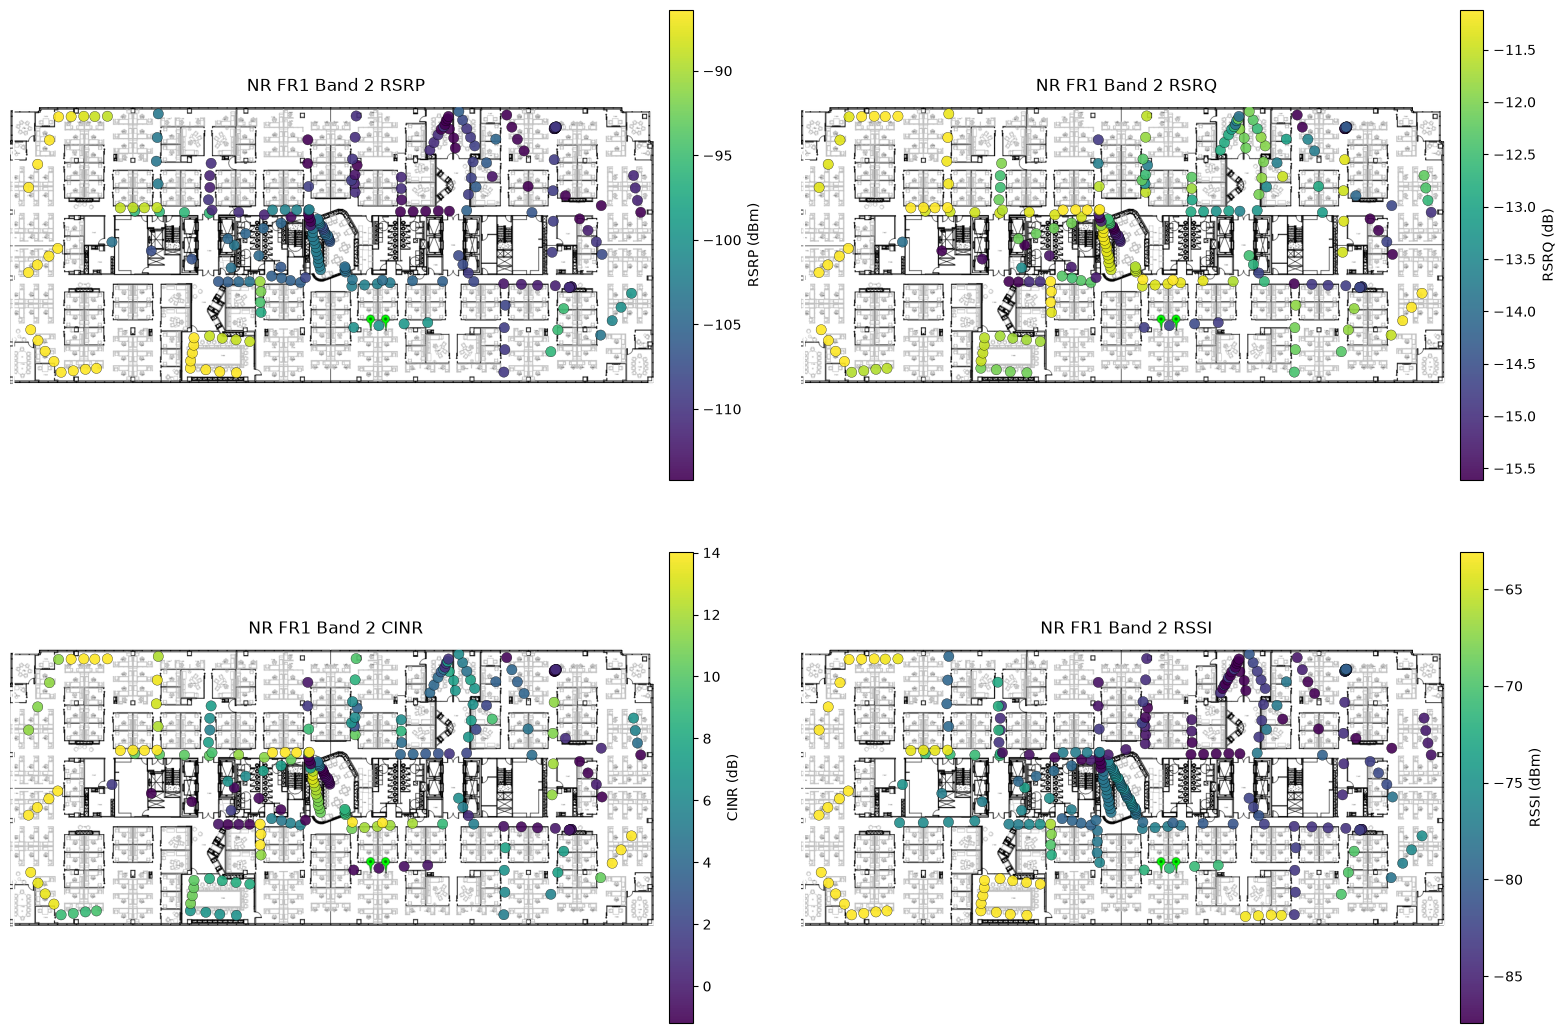

affine fit rmse: 0.0 px over 3 GCPs


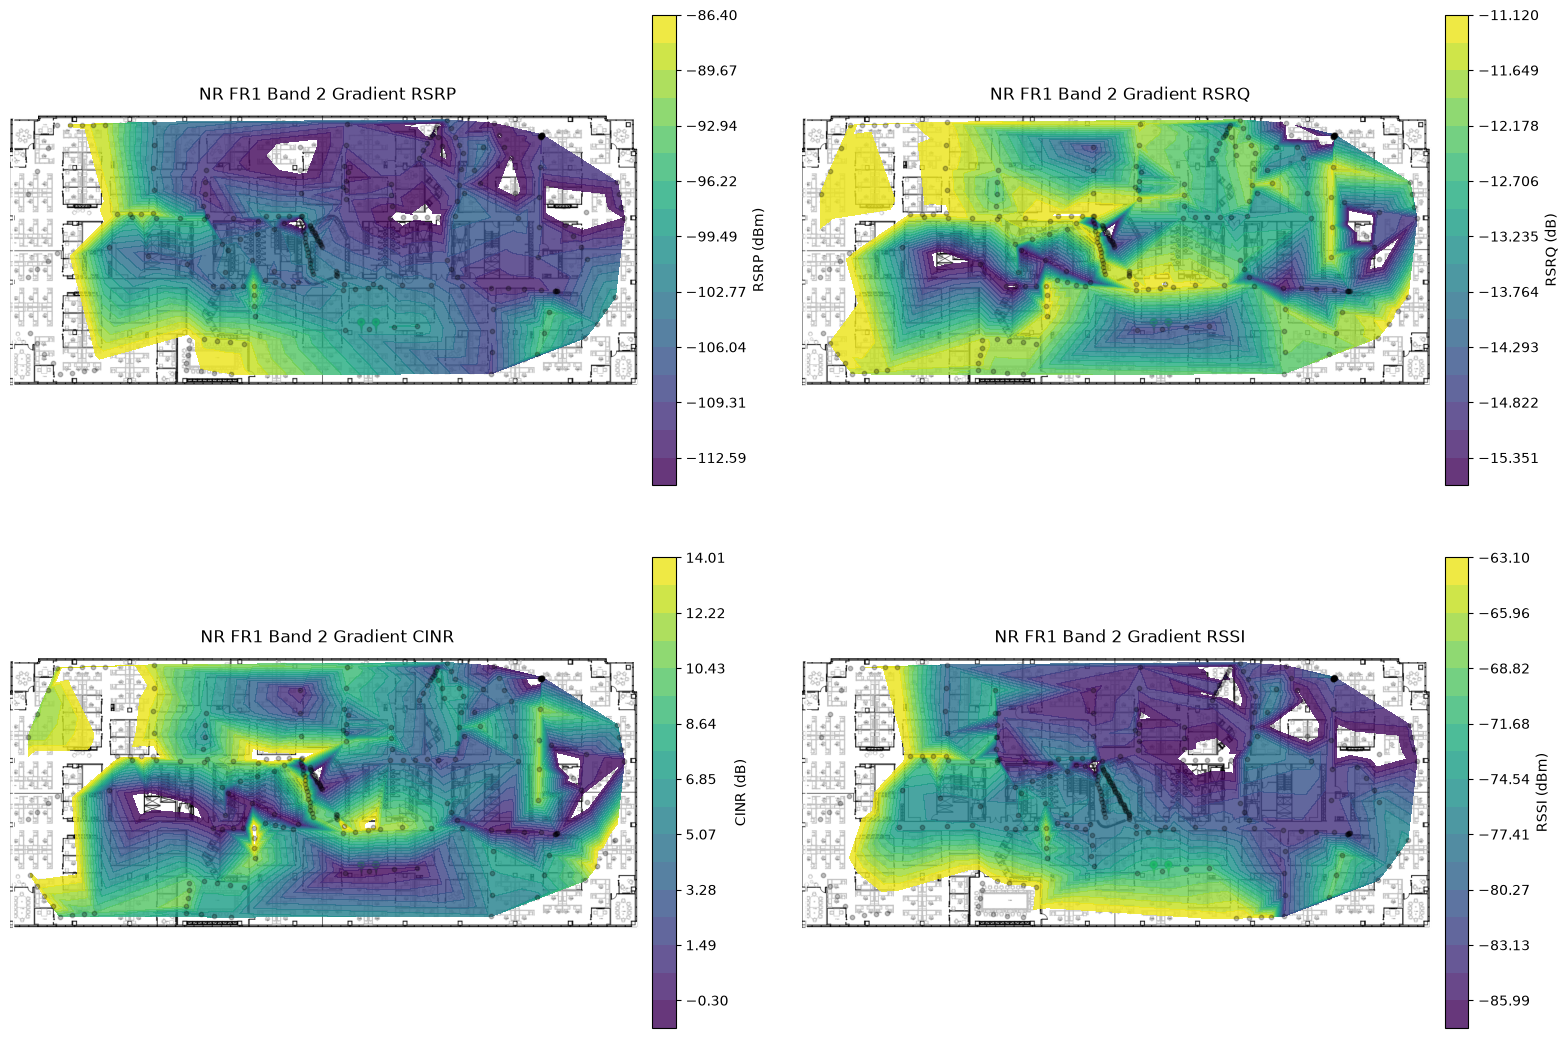

In [10]:
nr_topn_metrics_df = prepare_nr_topn_metrics_dataframe(CSV_DIR)
nr_fr1_band2_df = nr_topn_metrics_df[
    (nr_topn_metrics_df['network'] == 'nr_fr1') &
    (nr_topn_metrics_df['band'] == 2)
].copy()
nr_fr1_band2_avg_df = average_metrics_by_coordinate(nr_fr1_band2_df)

print(f'nr_fr1_band2_rows={len(nr_fr1_band2_df)}')
print(f'nr_fr1_band2_unique_coordinates={len(nr_fr1_band2_avg_df)}')
nr_fr1_band2_avg_df[['latitude', 'longitude', 'rsrp', 'rsrq', 'cinr', 'rssi', 'n_samples']].head()

plot_floor_metric_grid(nr_fr1_band2_avg_df, title_prefix='NR FR1 Band 2', quantiles=(0.10, 0.90))
plot_floor_metric_gradient_grid(nr_fr1_band2_avg_df, title_prefix='NR FR1 Band 2 Gradient', quantiles=(0.10, 0.90))